In [1]:
!pip install mediapipe==0.10.21 opencv-python pillow


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.2/81.2 MB 8.6 MB/s eta 0:00:00

In [2]:
import cv2
import mediapipe as mp
from PIL import Image, ImageOps
import os

mp_face = mp.solutions.face_detection
face = mp_face.FaceDetection(model_selection=1, min_detection_confidence=0.5)

def make_polaroid(filename, output_name="final_polaroid.png"):
    img = cv2.imread(filename)
    h, w, _ = img.shape

    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = face.process(rgb)

    # ---- Detect all faces (for group support) ----
    if results.detections:
        xs, ys, xe, ye = [], [], [], []

        for d in results.detections:
            b = d.location_data.relative_bounding_box
            x1 = int(b.xmin * w)
            y1 = int(b.ymin * h)
            x2 = x1 + int(b.width * w)
            y2 = y1 + int(b.height * h)

            xs.append(x1)
            ys.append(y1)
            xe.append(x2)
            ye.append(y2)

        x = min(xs)
        y = min(ys)
        bw = max(xe) - x
        bh = max(ye) - y
    else:
        # fallback center crop
        x = w//4
        y = h//4
        bw = w//2
        bh = h//2

    # ---- Expand box naturally (camera-style framing) ----
    padx = int(bw * 0.4)
    pady = int(bh * 0.6)

    x1 = max(0, x - padx)
    y1 = max(0, y - pady)
    x2 = min(w, x + bw + padx)
    y2 = min(h, y + bh + pady)

    crop = img[y1:y2, x1:x2]

    # ---- Convert to square ----
    crop_pil = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))

    size = min(crop_pil.width, crop_pil.height)
    crop_pil = crop_pil.crop((0, 0, size, size))
    crop_pil = crop_pil.resize((600, 600))

    # ---- Add Polaroid frame ----
    final = ImageOps.expand(crop_pil, border=(40,40,40,100), fill="white")

    final.save(output_name)
    return final


In [10]:
from google.colab import files
uploaded = files.upload()


Saving Screenshot 2026-02-19 133654.png to Screenshot 2026-02-19 133654.png


In [11]:
import os
os.listdir()


['.config',
 'Screenshot 2026-02-19 133654.png',
 'final_polaroid.png',
 'shilpa.jpeg',
 'shilpa (1).jpeg',
 'sample_data']

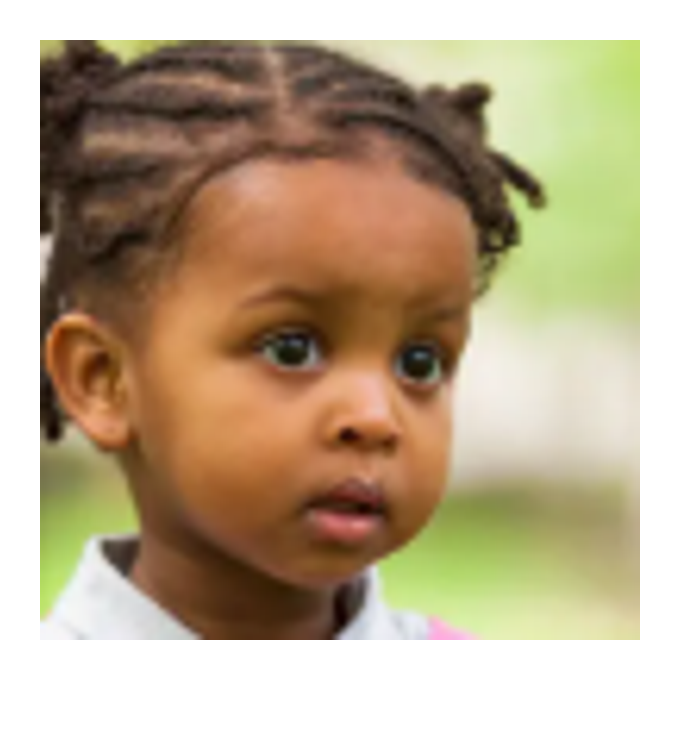

In [12]:
make_polaroid("Screenshot 2026-02-19 133654.png")
